# DL067 分布式训练的基本语义

真实按序执行，包含完整重训、可复核输出与内嵌图。所有新输出写入notebook_outputs。

In [1]:
from pathlib import Path
import sys, json, copy, numpy as np, torch
import experiment as e
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    b=BytesIO(); fig.savefig(b,format='png',dpi=135,bbox_inches='tight')
    display(Image(data=b.getvalue())); plt.close(fig)
torch.set_num_threads(1)
print({'python':sys.version.split()[0],'torch':torch.__version__,'unit':Path.cwd().name,'device':'CPU'})

{'python': '3.12.14', 'torch': '2.14.1+cpu', 'unit': '067', 'device': 'CPU'}


## 1 全局目标与不等rank

这里的rank是模型副本，没有网络。

In [2]:
x,y=e.data();m=e.model();parts=[torch.arange(20),torch.arange(20,50),torch.arange(50,128)]
rows=[e.gradient(copy.deepcopy(m),x[p],y[p]) for p in parts]
full=e.flatten(e.gradient(copy.deepcopy(m),x,y)[0])
for mode in ['weighted','rank_mean','double_divide']:
    g=e.flatten(e.average_gradients([z[0] for z in rows],[z[1] for z in rows],mode))
    print(mode,float((g-full).abs().max()))

weighted 8.326672684688674e-17
rank_mean 0.01640647936507697
double_divide 0.09796004452992152


## 2 实际采样器索引

调用DistributedSampler不等于启动了DDP。

In [3]:
for drop in [False,True]:
    parts=e.sampler_indices(drop_last=drop);flat=sum(parts,[])
    print('drop_last',drop,parts,'rows',len(flat),'unique',len(set(flat)))
print('epoch0',e.sampler_indices(shuffle=True,epoch=0));print('epoch1',e.sampler_indices(shuffle=True,epoch=1))

drop_last False [[0, 3, 6, 9], [1, 4, 7, 0], [2, 5, 8, 1]] rows 12 unique 10
drop_last True [[0, 3, 6], [1, 4, 7], [2, 5, 8]] rows 9 unique 9
epoch0 [[9, 0, 7, 1], [5, 3, 2, 9], [4, 8, 6, 5]]
epoch1 [[9, 4, 3, 7], [8, 6, 5, 9], [0, 2, 1, 8]]


## 3 数学语义与边界测试

含掩码、局部零计数、无效全局计数与采样覆盖。

In [4]:
import unittest, test_experiment
result=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
if not result.wasSuccessful(): raise RuntimeError('unit tests failed')

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 14 tests in 0.725s

OK


## 4 真正训练但仅模拟通信

执行三种子四模式，每个80次更新。

In [5]:
r=e.main(Path('notebook_outputs'))
print(r['execution_kind'])
for z in r['runs']: print(z['seed'],z['history'][-1])

single-process mathematical simulation; no real ranks or collective communication
11 {'step': 80, 'full': {'test_accuracy': 0.916015625, 'test_loss': 0.22250540677571704}, 'weighted': {'test_accuracy': 0.916015625, 'test_loss': 0.22250540677571704}, 'rank_mean': {'test_accuracy': 0.912109375, 'test_loss': 0.25499236631686156}, 'duplicated_rank': {'test_accuracy': 0.87109375, 'test_loss': 0.3963043638545797}, 'full_weighted_parameter_max_error': 4.440892098500626e-16}
23 {'step': 80, 'full': {'test_accuracy': 0.919921875, 'test_loss': 0.21005973940162115}, 'weighted': {'test_accuracy': 0.919921875, 'test_loss': 0.21005973940162115}, 'rank_mean': {'test_accuracy': 0.91796875, 'test_loss': 0.23258846184537688}, 'duplicated_rank': {'test_accuracy': 0.873046875, 'test_loss': 0.411232906394035}, 'full_weighted_parameter_max_error': 3.885780586188048e-16}
37 {'step': 80, 'full': {'test_accuracy': 0.923828125, 'test_loss': 0.1833021742723039}, 'weighted': {'test_accuracy': 0.923828125, 'test_l

## 5 训练曲线与权重误差

错误rank平均改变权重，重复rank改变覆盖。

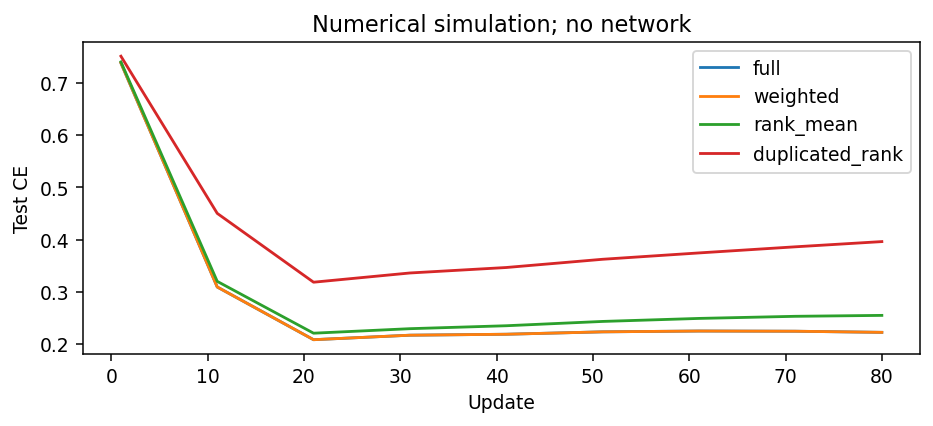

parameter errors [4.440892098500626e-16, 3.885780586188048e-16, 5.551115123125783e-16]


In [6]:
fig,ax=plt.subplots(figsize=(8,3))
h=r['runs'][0]['history']
for mode in ['full','weighted','rank_mean','duplicated_rank']:ax.plot([z['step'] for z in h],[z[mode]['test_loss'] for z in h],label=mode)
ax.set(xlabel='Update',ylabel='Test CE',title='Numerical simulation; no network');ax.legend();show(fig)
print('parameter errors',[z['history'][-1]['full_weighted_parameter_max_error'] for z in r['runs']])

## 6 通信公式不是计时

100MiB/12.5GB/s/5微秒假设下的理想环模型。

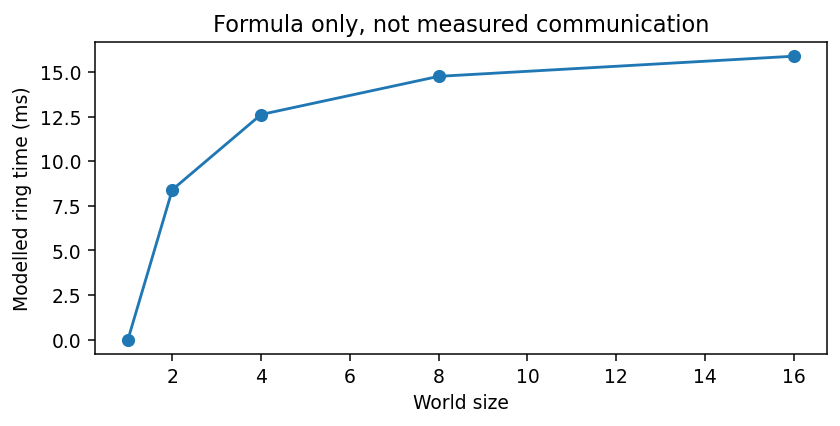

{'status': 'not_run', 'reason': 'this lesson verifies numerical semantics on CPU, not network or multi-process behavior'}


In [7]:
fig,ax=plt.subplots(figsize=(7,3))
a=r['communication_model'];ax.plot([z['world'] for z in a],[z['seconds']*1000 for z in a],'o-')
ax.set(xlabel='World size',ylabel='Modelled ring time (ms)',title='Formula only, not measured communication');show(fig)
print(r['real_distributed_run'])

## 7 全部终点权重复核

统一FP64结构，在保存的测试集计算。

In [8]:
a=np.load('notebook_outputs/data.npz')
for row in r['runs']:
    for mode in ['full','weighted','rank_mean','duplicated_rank']:
        z=torch.load(f"notebook_outputs/{mode}_seed{row['seed']}.pt",weights_only=True);m=e.model(z['seed']);m.load_state_dict(z['state_dict'])
        with torch.no_grad():v=float(torch.nn.functional.cross_entropy(m(torch.from_numpy(a['test_x'])),torch.from_numpy(a['test_y'])))
        if abs(v-row['history'][-1][mode]['test_loss'])>1e-12:raise RuntimeError('checkpoint mismatch')
print('12 checkpoints reproduced')

12 checkpoints reproduced
